In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import mosqlient as mosq
from epiweeks import Week
from aux_func import get_data
from analysis import * 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
from mosqlient.prediction_optimize import get_df_pars_ls

In [3]:
code_to_state = {33: 'RJ', 32: 'ES', 41: 'PR', 23: 'CE', 21: 'MA',
 31: 'MG', 42: 'SC', 26: 'PE', 25: 'PB', 24: 'RN', 22: 'PI', 27: 'AL',
 28: 'SE', 35: 'SP', 43: 'RS', 15: 'PA', 16: 'AP', 14: 'RR',  11: 'RO',
 13: 'AM', 12: 'AC', 51: 'MT', 50: 'MS', 52: 'GO', 17: 'TO', 53: 'DF',
 29: 'BA'}

state_to_code = {value: key for key, value in code_to_state.items()}

geo_dengue = [2931350,2933307,2302503,3119401,
              3549805,3541406,1200401,1200203,
              1716109,4113700,4103701,4104808,
              5201405,5102637,5215231]

geo_chik = [2211001,2931350,3143302,3119401,
            1721000,1716109,4104808,4219507,
            5103403,5102637] 

In [4]:
df_dengue_state, df_dengue_city  = get_data(disease = 'dengue')
df_dengue_state.date = pd.to_datetime(df_dengue_state.date)
#df_chik_state, df_chik_city  = get_data(disease = 'chikungunya')

In [5]:
challenge = 'dengue_state'

df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [6]:
df_dengue_state = df_dengue_state.merge(
        df_preds[["date", "adm_1", "validation"]].drop_duplicates(
                subset=["date", "adm_1", "validation"],
                keep="first"
            ), on=["date", "adm_1"]
    )

df_dengue_state.head()

,date,adm_1,casos,validation
0,2022-10-09,11,99,1
1,2022-10-09,12,31,1
2,2022-10-09,13,250,1
3,2022-10-09,14,2,1
4,2022-10-09,15,60,1


In [7]:
state =  41
validation =2 

model =  '3rd_imdc_isi_isi-dengue'

df_preds_m = df_preds.loc[(df_preds.model == model) & (df_preds.adm_1 == state)]

df_pars = get_df_pars_ls(df_preds_m)

df_pars.loc[df_pars.sigma == 0, 'sigma'] = 0.1


In [11]:
rho = estimate_rho(df_pars.loc[(df_pars.validation == validation-1)].merge(df_dengue_state, on = ['date', 'adm_1', 'validation'], how = 'left'))

rho

np.float64(0.9003280748197985)

In [12]:
marginals_uf = build_marginals(df_pars, state, 2)

n_paths = 1000

rng = np.random.default_rng(0)

paths = np.vstack([
    sample_path(marginals_uf, rho, random_state=rng)
    for _ in range(n_paths)
])

season_total = paths.sum(axis=1)     # cumulative cases over the horizon
season_peak  = paths.max(axis=1)     # peak weekly cases

for name, q in [('total', season_total), ('peak', season_peak)]:
    lo, med, hi = np.quantile(q, [0.025, 0.5, 0.975])
    print(f'{name:5s}  median={med:,.0f}  95% PI=[{lo:,.0f}, {hi:,.0f}]')

total  median=202,923  95% PI=[181,387, 227,397]
peak   median=9,437  95% PI=[7,925, 11,285]


In [13]:
r0_dist = []
pico_dist = []

indices_aleatorios = rng.choice(paths.shape[0], size=100, replace=False)

amostras_paths = paths[indices_aleatorios, :]

print("Ajustando curvas de Richards para os caminhos amostrados...")
for path in amostras_paths:
    r0_i, pico_i = otim_single_path(path)
    r0_dist.append(r0_i)
    pico_dist.append(pico_i)


r0_dist = np.array(r0_dist)
pico_dist = np.array(pico_dist)

for name, q in [('R0', r0_dist), ('peak', pico_dist)]:
    lo, med, hi = np.quantile(q, [0.025, 0.5, 0.975])
    print(f'{name:5s}  median={med:,.2f}  95% PI=[{lo:,.2f}, {hi:,.2f}]')

Ajustando curvas de Richards para os caminhos amostrados...
R0     median=1.42  95% PI=[1.41, 1.44]
peak   median=27.06  95% PI=[26.44, 27.80]


In [14]:
r0_dist = []
pico_dist = []

indices_aleatorios = rng.choice(paths.shape[0], size=10, replace=False)

amostras_paths = paths[indices_aleatorios, :]

print("Ajustando curvas de Richards para os caminhos amostrados...")
for path in amostras_paths:
    r0_i, pico_i = otim_single_path(path)
    r0_dist.append(r0_i)
    pico_dist.append(pico_i)


r0_dist = np.array(r0_dist)
pico_dist = np.array(pico_dist)

for name, q in [('R0', r0_dist), ('peak', pico_dist)]:
    lo, med, hi = np.quantile(q, [0.025, 0.5, 0.975])
    print(f'{name:5s}  median={med:,.2f}  95% PI=[{lo:,.2f}, {hi:,.2f}]')

Ajustando curvas de Richards para os caminhos amostrados...
R0     median=1.42  95% PI=[1.41, 1.43]
peak   median=27.25  95% PI=[26.45, 28.01]


In [15]:
int(np.median(pico_dist))

27

### All validations and models: 

In [16]:
def process_single_combination(df_preds, df_dengue_state, state, model, validation, n_paths=1000, n_samples=10, seed=0):
    """
    Processa a simulação e métricas para uma única combinação de modelo e validação.
    """
    rng = np.random.default_rng(seed)
    
    # 1. Filtragem e preparação de parâmetros
    df_preds_m = df_preds.loc[(df_preds.model == model) & (df_preds.adm_1 == state)]
    if df_preds_m.empty:
        return None  # Retorna None se não houver dados para essa combinação
        
    df_pars = get_df_pars_ls(df_preds_m)
    df_pars.loc[df_pars.sigma == 0, 'sigma'] = 0.1

    # 2. Estimativa de Rho e Marginais
    df_rho_input = df_pars.loc[(df_pars.validation == validation - 1)].merge(
        df_dengue_state, on=['date', 'adm_1', 'validation'], how='left'
    )
    rho = estimate_rho(df_rho_input)
    marginals_uf = build_marginals(df_pars, state, validation)

    # 3. Geração das trajetórias (paths)
    paths = np.vstack([
        sample_path(marginals_uf, rho, random_state=rng)
        for _ in range(n_paths)
    ])

    # 4. Cálculo das métricas baseadas em todas as trajetórias
    season_total = paths.sum(axis=1)
    season_peak = paths.max(axis=1)

    # 5. Amostragem para ajuste da curva de Richards
    indices_aleatorios = rng.choice(paths.shape[0], size=n_samples, replace=False)
    amostras_paths = paths[indices_aleatorios, :]

    r0_dist = []
    pico_dist = []
    for path in amostras_paths:
        r0_i, pico_i = otim_single_path(path)
        r0_dist.append(r0_i)
        pico_dist.append(pico_i)

    r0_dist = np.array(r0_dist)
    pico_dist = np.array(pico_dist)

    # 6. Consolidação dos resultados em um dicionário de intervalos
    metrics = {
        'model': model,
        'validation': validation,
        'state': state
    }
    
    # Dicionário mapeando o nome da métrica para o seu array de distribuição
    distributions = {
        'season_total': season_total,
        'season_peak': season_peak,
        'r0_dist': r0_dist,
        'pico_dist': pico_dist
    }
    
    # Calcula os quantis automaticamente para cada métrica
    for name, dist in distributions.items():
        lo, med, hi = np.quantile(dist, [0.025, 0.5, 0.975])
        metrics[f'{name}_p25'] = lo
        metrics[f'{name}_p50'] = med
        metrics[f'{name}_p975'] = hi

    return metrics

In [17]:
def run_pipeline(df_preds, df_dengue_state, state, models_list, validations_list):
    """
    Executa o loop por todos os modelos e validações e retorna um DataFrame consolidado.
    """
    results = []
    
    for model in models_list:
        for validation in validations_list:
            print(f"Processando: Modelo={model} | Validation={validation}...")
            try:
                res = process_single_combination(df_preds, df_dengue_state, state, model, validation)
                if res is not None:
                    results.append(res)
            except Exception as e:
                print(f"Erro ao processar Modelo={model}, Validation={validation}: {e}")
                continue
                
    # Transforma a lista de dicionários em um DataFrame estruturado
    df_results = pd.DataFrame(results)
    return df_results

In [18]:
# Listas de modelos e validações que você quer rodar
lista_modelos = df_preds.model.unique()
lista_validations = [2]
state_alvo = 41

# Executa o pipeline
df_final_resultados = run_pipeline(df_preds, df_dengue_state, state_alvo, lista_modelos, lista_validations)

# Salva os resultados em um arquivo
df_final_resultados

Processando: Modelo=3rd_imdc_isi_isi-dengue | Validation=2...
Processando: Modelo=3rd_imdc_purdue_neuralearth | Validation=2...
Processando: Modelo=3rd_imdc_fiocruz_mard | Validation=2...
Processando: Modelo=3rd_imdc_bsc_ghr | Validation=2...
Processando: Modelo=3rd_imdc_fgv_pattern-blue | Validation=2...
Processando: Modelo=3rd_imdc_lncc_lncc_arp26_dengue | Validation=2...
Processando: Modelo=3rd_imdc_procc_bb_model | Validation=2...
Processando: Modelo=3rd_imdc_unesp_recogna | Validation=2...
Processando: Modelo=3rd_imdc_ifgw_inframind-proteus | Validation=2...
Processando: Modelo=DS-OKSTATE-2026 | Validation=2...
Processando: Modelo=3rd_imdc_ceri_returnoftheforecast | Validation=2...
Processando: Modelo=3rd_imdc_nus_nus-cerm | Validation=2...
Processando: Modelo=3rd_imdc_lncc_surge_model26_dengue | Validation=2...
Processando: Modelo=3rd_imdc_pucrio_arbocaster | Validation=2...
Processando: Modelo=3rd_imdc_emap_lstm | Validation=2...
Processando: Modelo=3rd_imdc_emap_xgbsillas | Val

,model,validation,state,season_total_p25,season_total_p50,season_total_p975,season_peak_p25,season_peak_p50,season_peak_p975,r0_dist_p25,r0_dist_p50,r0_dist_p975,pico_dist_p25,pico_dist_p50,pico_dist_p975
0,3rd_imdc_isi_isi-dengue,2,41,181386.883146,202922.709396,2.273969e+05,7925.431541,9436.715138,11284.742951,1.402297,1.423212,1.436683,26.479378,27.435677,28.219968
1,3rd_imdc_purdue_neuralearth,2,41,9610.312661,66433.290835,4.388755e+05,519.653400,3831.822248,26407.816652,1.509596,1.629063,1.688185,24.654861,25.343374,26.198097
2,3rd_imdc_fiocruz_mard,2,41,64791.078067,89379.469517,1.212180e+05,4420.475928,6068.746006,8192.692905,1.739204,1.740779,1.742578,24.779735,24.788188,24.795537
3,3rd_imdc_bsc_ghr,2,41,5209.570168,19739.802898,6.976620e+04,376.615929,1397.718733,4838.677721,1.708646,1.716238,1.725114,25.600992,25.625116,25.652873
4,3rd_imdc_fgv_pattern-blue,2,41,113940.149623,202320.614598,3.540232e+05,10158.490118,16517.402429,26173.001895,1.615428,1.667940,1.737640,26.098231,26.118151,26.134646
5,3rd_imdc_lncc_lncc_arp26_dengue,2,41,2824.168016,34962.680116,3.803091e+05,214.845563,2650.206453,28624.894022,1.184012,1.188591,1.191634,27.468205,27.497883,27.545770
6,3rd_imdc_procc_bb_model,2,41,5510.432796,66516.708626,7.045228e+05,354.288989,4116.501771,44637.696019,1.644453,1.646380,1.648243,24.965260,25.019177,25.079745
7,3rd_imdc_unesp_recogna,2,41,1898.297633,5029.534364,1.138964e+05,267.732576,547.226255,5097.293404,1.632611,1.669077,1.677454,35.000000,35.000000,35.000000
8,3rd_imdc_ifgw_inframind-proteus,2,41,3616.069319,31655.182183,2.569188e+05,277.374090,2262.007456,16503.375900,1.696891,1.748436,1.804606,24.816648,25.015990,25.225532
9,DS-OKSTATE-2026,2,41,55513.125792,65351.915441,8.078835e+04,3841.435944,4416.280195,5039.718797,1.719580,1.756020,1.785388,25.491182,25.492098,25.503894


In [19]:
cases_slice = df_dengue_state.loc[(df_dengue_state.adm_1 == state) & (df_dengue_state.validation == validation)]
r0, pico = otim_single_path(cases_slice.casos.values)
print(pico)

25.449824157775744


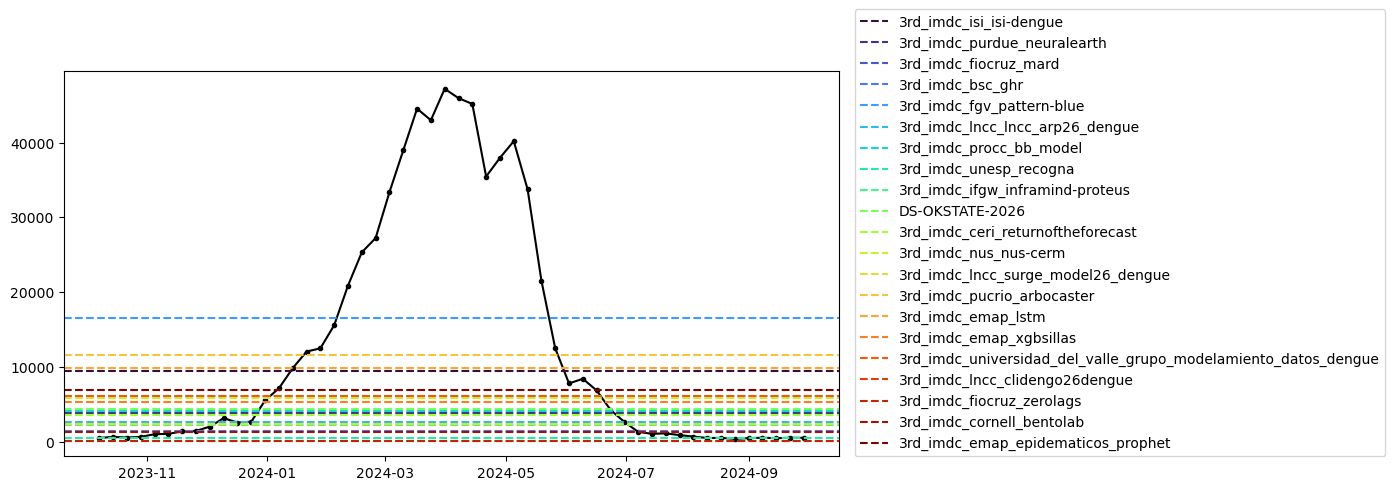

In [20]:
n_modelos = 21
cores = plt.colormaps['turbo'](np.linspace(0, 1, n_modelos))

_,ax = plt.subplots(figsize = (10, 5))

ax.plot(cases_slice.date, cases_slice.casos, color = 'black', marker = '.')


for m, cor in zip(df_final_resultados.model, cores): 

    peak_height = int(df_final_resultados.loc[df_final_resultados.model == m]['season_peak_p50'].values[0])

    ax.axhline(peak_height, label = m, linestyle = '--', color = cor)

ax.legend(loc = (1.02, 0))

plt.show()

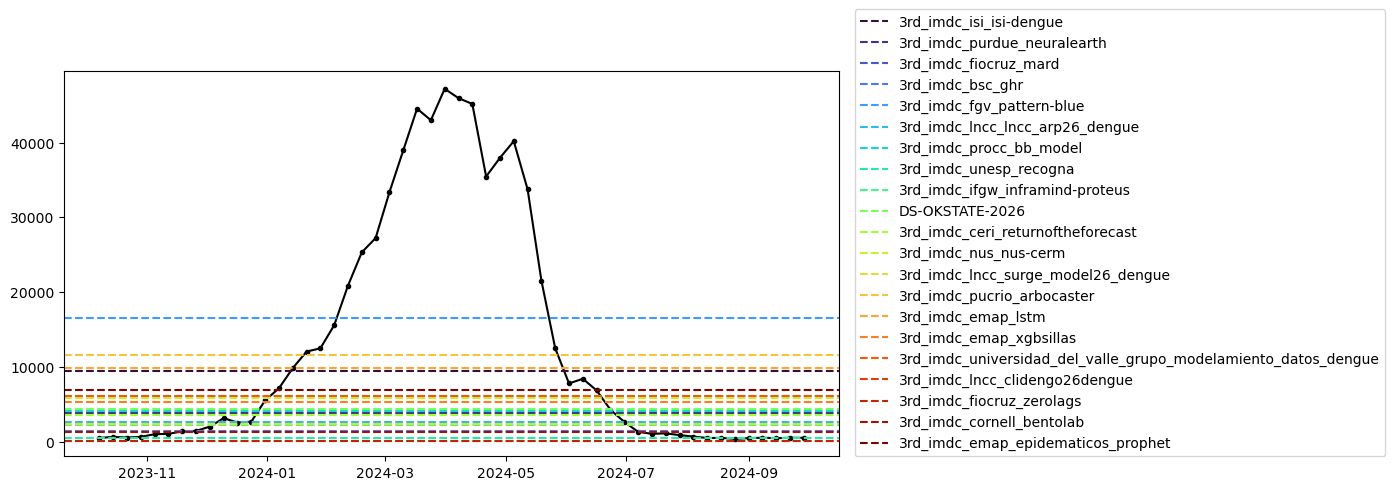

In [21]:
n_modelos = 21
cores = plt.colormaps['turbo'](np.linspace(0, 1, n_modelos))

_,ax = plt.subplots(figsize = (10, 5))

ax.plot(cases_slice.date, cases_slice.casos, color = 'black', marker = '.')


for m, cor in zip(df_final_resultados.model, cores): 

    peak_height = int(df_final_resultados.loc[df_final_resultados.model == m]['season_peak_p50'].values[0])

    ax.axhline(peak_height, label = m, linestyle = '--', color = cor)

ax.legend(loc = (1.02, 0))

plt.show()

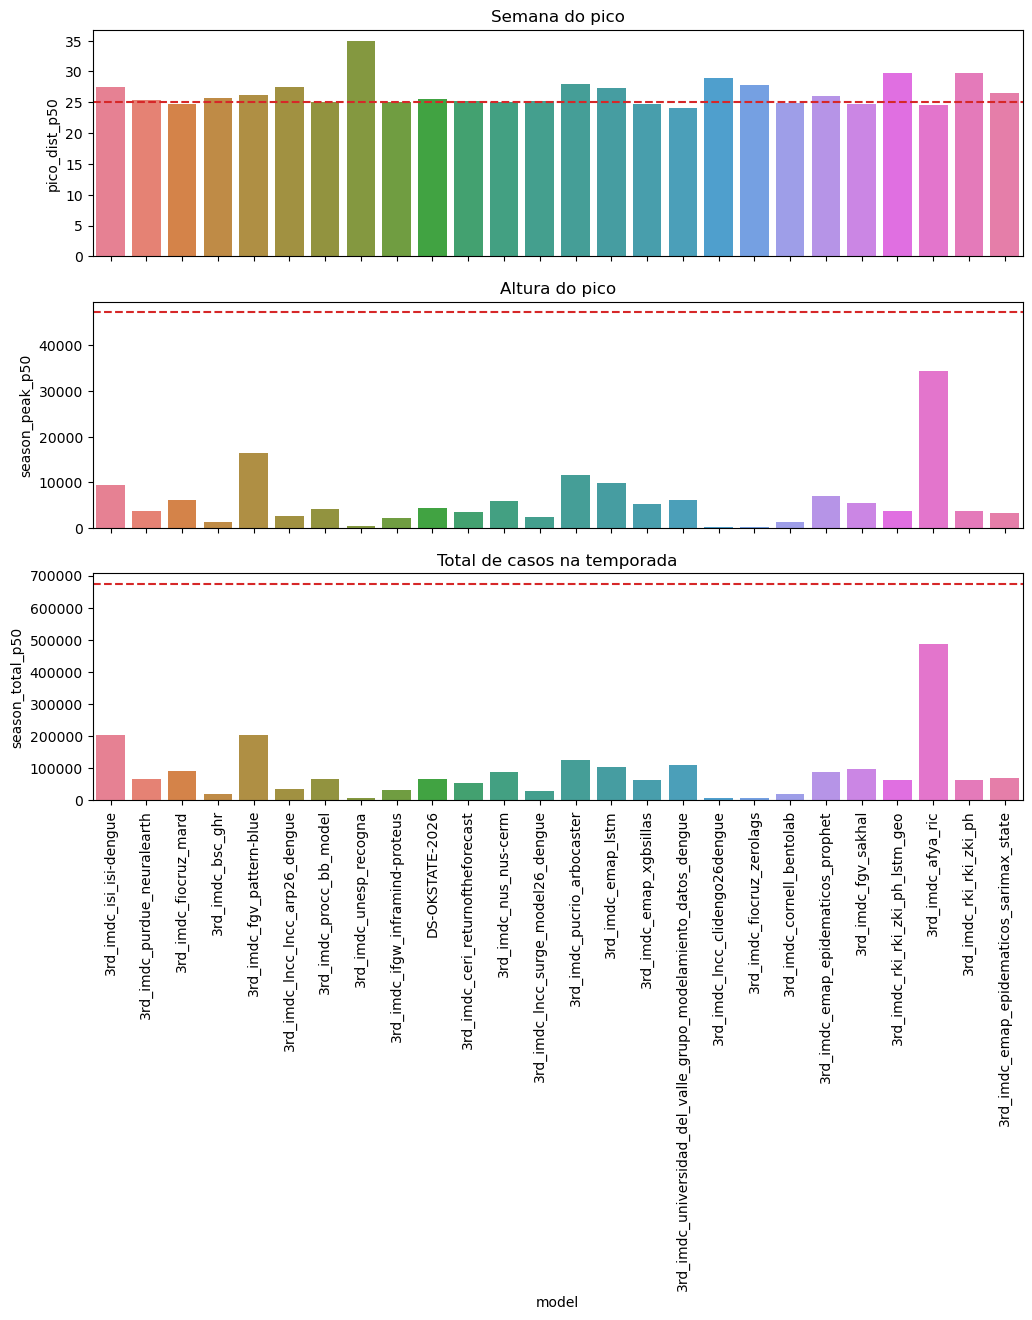

In [22]:
_,ax = plt.subplots(3,1, figsize = (12, 10), sharex=True)

sns.barplot(ax= ax[0], data = df_final_resultados, x = 'model', y = 'pico_dist_p50', hue = 'model')
ax[0].axhline(int(pico), color = 'tab:red', linestyle = '--', label = 'Truth')
ax[0].set_title('Semana do pico')

sns.barplot(ax= ax[1], data = df_final_resultados, x = 'model', y = 'season_peak_p50', hue = 'model')
ax[1].axhline(int(max(cases_slice.casos)), color = 'tab:red', linestyle = '--', label = 'Truth')
ax[1].set_title('Altura do pico')

sns.barplot(ax= ax[2], data = df_final_resultados, x = 'model', y = 'season_total_p50', hue = 'model')
ax[2].axhline(int(sum(cases_slice.casos)), color = 'tab:red', linestyle = '--', label = 'Truth')
ax[2].set_title('Total de casos na temporada')

ax[2].tick_params(axis = 'x', rotation = 90)
plt.show()

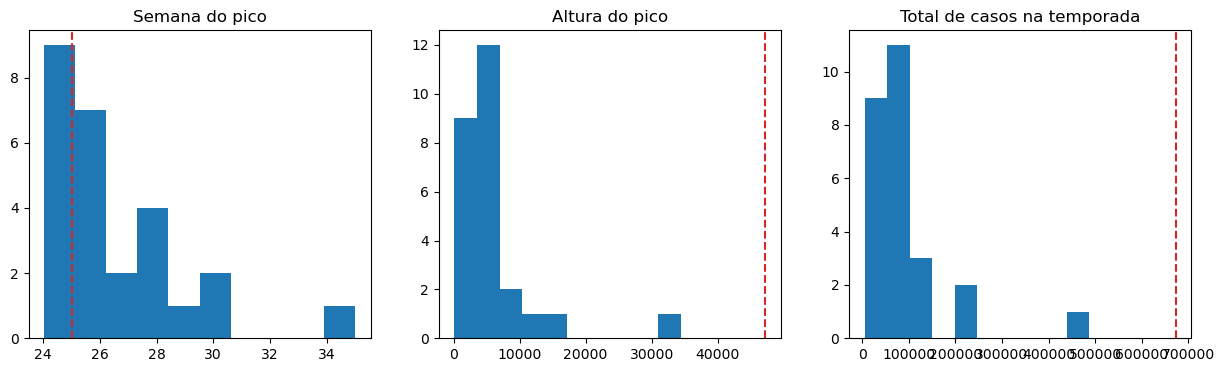

In [29]:
_,ax = plt.subplots(1,3, figsize = (15, 4), sharex=False)

ax[0].hist(df_final_resultados['pico_dist_p50'])
ax[0].axvline(int(pico), color = 'tab:red', linestyle = '--', label = 'Truth')
ax[0].set_title('Semana do pico')

#sns.barplot(ax= ax[1], data = df_final_resultados, x = 'model', y = 'season_peak_p50', hue = 'model')
ax[1].hist(df_final_resultados['season_peak_p50'])
ax[1].axvline(int(max(cases_slice.casos)), color = 'tab:red', linestyle = '--', label = 'Truth')
ax[1].set_title('Altura do pico')

#sns.barplot(ax= ax[2], data = df_final_resultados, x = 'model', y = 'season_total_p50', hue = 'model')
ax[2].hist(df_final_resultados['season_total_p50'])
ax[2].axvline(int(sum(cases_slice.casos)), color = 'tab:red', linestyle = '--', label = 'Truth')
ax[2].set_title('Total de casos na temporada')

#ax[2].tick_params(axis = 'x', rotation = 90)
plt.show()